In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.linear_model import LinearRegression

In [190]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
#print(train_data.head())
#print(test_data.head())
print(train_data.describe())


                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

In [16]:
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [184]:
print(train_data["GarageYrBlt"].head(40))

0     2003.0
1     1976.0
2     2001.0
3     1998.0
4     2000.0
5     1993.0
6     2004.0
7     1973.0
8     1931.0
9     1939.0
10    1965.0
11    2005.0
12    1962.0
13    2006.0
14    1960.0
15    1991.0
16    1970.0
17    1967.0
18    2004.0
19    1958.0
20    2005.0
21    1930.0
22    2002.0
23    1976.0
24    1968.0
25    2007.0
26    2005.0
27    2008.0
28    1957.0
29    1920.0
30    1920.0
31    1966.0
32    2007.0
33    1959.0
34    2005.0
35    2004.0
36    1995.0
37    1954.0
38    1953.0
39       NaN
Name: GarageYrBlt, dtype: float64


In [93]:
# drop columns with too many null values
missing=[]
for i in train_data.columns:
    missing.append(train_data[i].isna().sum()/len(train_data))
missing = pd.Series(missing, index=train_data.columns)
print(missing.sort_values(ascending=False).head(20))
print(missing[missing > 0.8].index.tolist())
train_data = train_data.drop(missing[missing>0.8].index, axis=1)
len(list(train_data.columns))

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
GarageQual      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
Id              0.000000
dtype: float64
['Alley', 'PoolQC', 'Fence', 'MiscFeature']


77

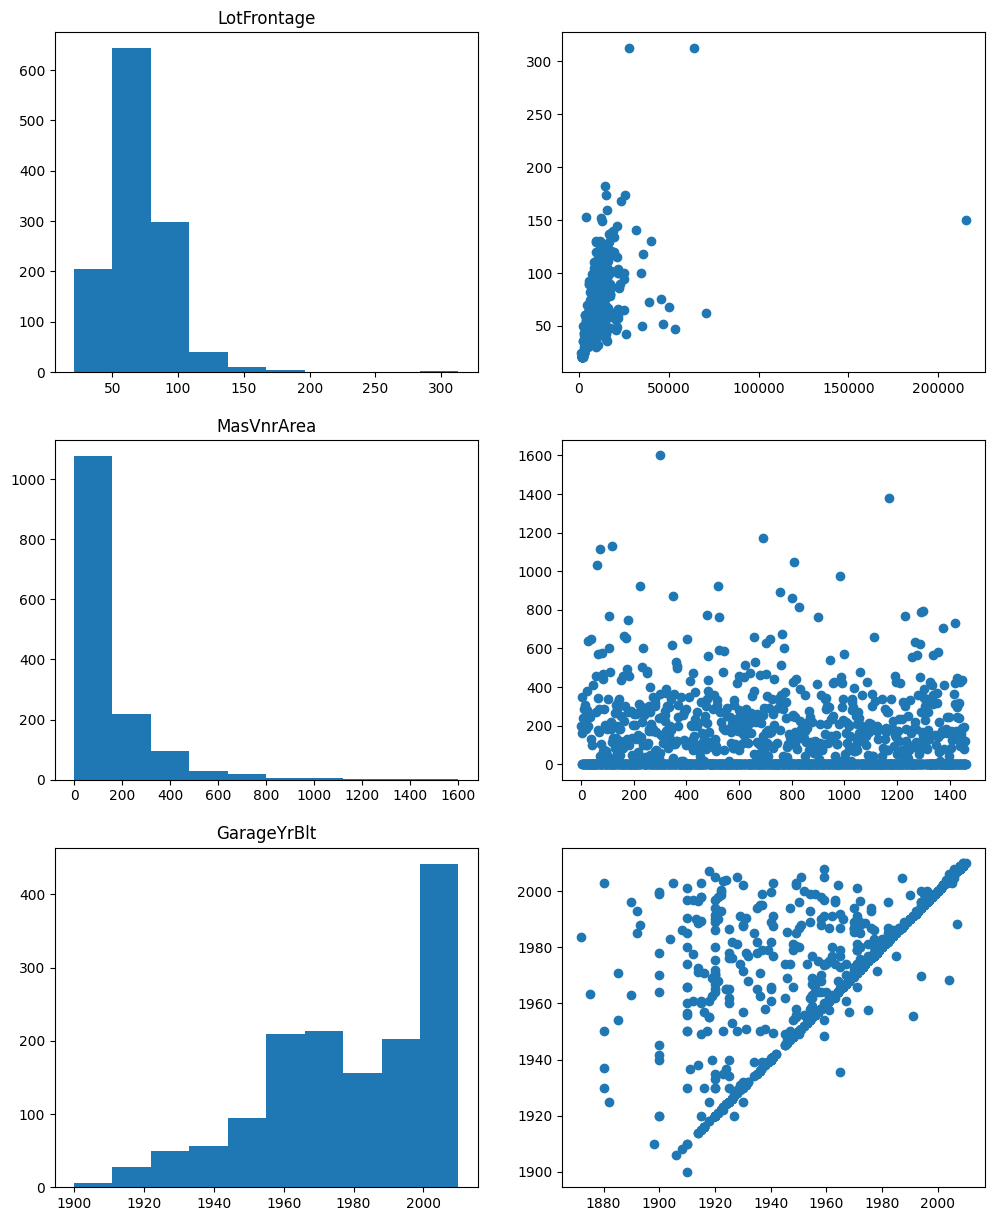

In [135]:
# plots of numeric features with missing values
columns_w_missing = missing[(missing > 0) & (missing < 0.8)].index.tolist()
df = train_data[columns_w_missing]
df = df[df.select_dtypes(include=np.number).columns]
fig, axes = plt.subplots(nrows=len(df.columns), ncols=2, figsize=(12, 5 * len(df.columns)))
axes[0, 0].hist(df["LotFrontage"])
axes[0, 0].set_title("LotFrontage")
axes[0, 1].scatter(train_data["LotArea"], df["LotFrontage"])

axes[1, 0].hist(df["MasVnrArea"])
axes[1, 0].set_title("MasVnrArea")
axes[1, 1].scatter(train_data["Id"], df["MasVnrArea"])

axes[2, 0].hist(df["GarageYrBlt"])
axes[2, 0].set_title("GarageYrBlt")
axes[2, 1].scatter(train_data["YearBuilt"], df["GarageYrBlt"])

"""
for index, value in enumerate(df.columns):
    axes[index, 0].hist(df[str(value)])
    axes[index, 0].set_title(str(value))
    axes[index, 1].scatter(train_data["Id"], df[str(value)])
"""
plt.show()

In [191]:
# GarageYrBlt
lr = LinearRegression()
data = train_data.copy(deep=True)
null_indexes = np.where(data["GarageYrBlt"].isna())[0].tolist()
print(null_indexes)
data.dropna(subset=["GarageYrBlt"], inplace=True)
lr.fit(X=pd.DataFrame(data["YearBuilt"]), y=data["GarageYrBlt"])
pred = np.round(lr.predict(pd.DataFrame(train_data["YearBuilt"]).iloc[null_indexes]), 0)
train_data.loc[null_indexes, "GarageYrBlt"] = pred

[39, 48, 78, 88, 89, 99, 108, 125, 127, 140, 148, 155, 163, 165, 198, 210, 241, 250, 287, 291, 307, 375, 386, 393, 431, 434, 441, 464, 495, 520, 528, 533, 535, 562, 582, 613, 614, 620, 635, 636, 638, 649, 705, 710, 738, 750, 784, 826, 843, 921, 942, 954, 960, 968, 970, 976, 1009, 1011, 1030, 1038, 1096, 1123, 1131, 1137, 1143, 1173, 1179, 1218, 1219, 1234, 1257, 1283, 1323, 1325, 1326, 1337, 1349, 1407, 1449, 1450, 1453]


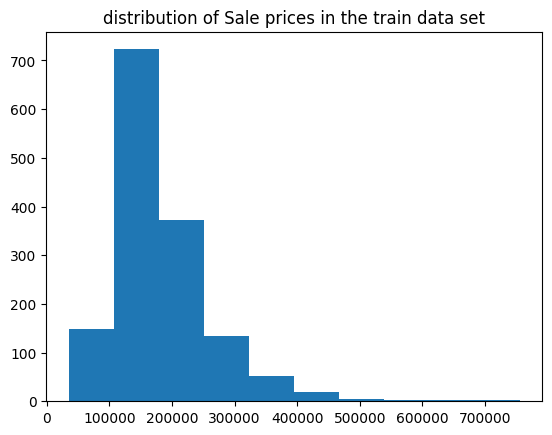

In [17]:
plt.hist(train_data["SalePrice"], bins=10)
plt.title("distribution of Sale prices in the train data set")
plt.show()

In [ ]:
X_train = train_data.drop("SalePrice", axis=1)
y_train = train_data["SalePrice"]
X_test = test_data